In [229]:
"""
Demonstration of the SOLID plant anatomy framework.

This script shows how to:
1. Create pine needle and root anatomies
2. Add and remove layers dynamically
3. Generate and visualize anatomical structures
4. Export data
"""

import matplotlib.pyplot as plt
from pine_needle_anatomy import PineNeedleAnatomy
from root_anatomy import RootAnatomy
from layer import Layer
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## ROOT ANATOMY DEMONSTRATION

In [230]:
# Create a root anatomy instance
root = RootAnatomy(randomness=1.0)

print(f"\nInitial layers: {root.list_layers()}")
print(f"Number of layers: {len(root.layer_manager)}")


Initial layers: ['epidermis', 'cortex', 'endodermis', 'pericycle']
Number of layers: 4


### 1. Generating initial structure...

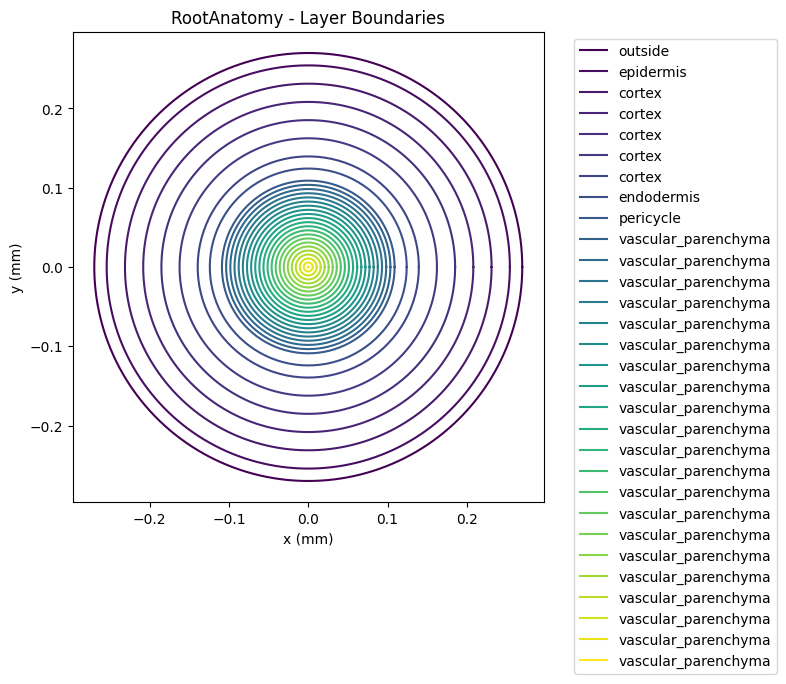

In [231]:
fig = root.plot_layers(show=True)
plt.savefig('output/root_initial_layers.png', dpi=150, bbox_inches='tight')
plt.close()

In [232]:
root._calculate_root_radius()

0.26

In [233]:
radius = root.vascular_params["thickness"] / 2

for layer in root.layer_manager.get_layers():
    if hasattr(layer, 'n_layers'):
        radius += layer.get_total_thickness()
    elif hasattr(layer, 'cell_diameter'):
        radius += layer.cell_diameter

print(radius)

0.26


In [234]:
root.layer_manager.expand_layers()

[{'name': 'epidermis', 'cell_diameter': 0.02, 'cell_width': 0},
 {'name': 'cortex', 'cell_diameter': 0.03, 'cell_width': 0},
 {'name': 'cortex', 'cell_diameter': 0.03, 'cell_width': 0},
 {'name': 'cortex', 'cell_diameter': 0.03, 'cell_width': 0},
 {'name': 'cortex', 'cell_diameter': 0.03, 'cell_width': 0},
 {'name': 'cortex', 'cell_diameter': 0.03, 'cell_width': 0},
 {'name': 'endodermis', 'cell_diameter': 0.02, 'cell_width': 0},
 {'name': 'pericycle', 'cell_diameter': 0.02, 'cell_width': 0}]

In [ ]:
layers_polygons = []
layer_array = root.layer_manager.expand_layers()
from geometry_processor import GeometryProcessor
polygon = root.generate_base_shape()

for i_layer, layer in enumerate(layer_array):
    if i_layer == 0:
        # Add outside layer
        space_increment = layer["cell_diameter"] / 2
        polygon = GeometryProcessor.buffer_polygon(
            polygon, space_increment, smooth_factor=0.01
        )
        layers_polygons.append({
            "name": "outside",
            "polygon": polygon,
            "cell_diameter": layer["cell_diameter"] / 3,
            "id_layer": i_layer,
            "cell_width": 0
        })
    
    # Add the layer polygon
    polygon = GeometryProcessor.buffer_polygon(
        polygon, 
        -space_increment / 2 - layer["cell_diameter"] / 4,
        smooth_factor=0.5
    )
    space_increment = layer["cell_diameter"] / 2
    
    cell_width = layer["cell_width"]
    param_match = root.layer_manager.get_layer(layer["name"])
    print(layer["name"], cell_width, param_match)
    print(param_match)
    print(param_match.cell_width)
    if param_match and param_match.cell_width:
        cell_width = param_match.cell_width / 4
    
    layers_polygons.append({
        "name": layer["name"],
        "polygon": polygon,
        "cell_diameter": layer["cell_diameter"],
        "id_layer": i_layer + 1,
        "cell_width": cell_width
    })

# Add central layers (vascular, parenchyma, etc.)
params = [l.to_dict() for l in root.layer_manager.get_layers()]
central_layers = root._create_central_layers(polygon, params)
layers_polygons.extend(central_layers)

epidermis 0 Layer(name='epidermis', diameter=0.0200, n_layers=1, order=5)
cortex 0 Layer(name='cortex', diameter=0.0300, n_layers=5, order=4)
cortex 0 Layer(name='cortex', diameter=0.0300, n_layers=5, order=4)
cortex 0 Layer(name='cortex', diameter=0.0300, n_layers=5, order=4)
cortex 0 Layer(name='cortex', diameter=0.0300, n_layers=5, order=4)
cortex 0 Layer(name='cortex', diameter=0.0300, n_layers=5, order=4)
endodermis 0 Layer(name='endodermis', diameter=0.0200, n_layers=1, order=3)
pericycle 0 Layer(name='pericycle', diameter=0.0200, n_layers=1, order=2)


### Generating cell structure (Voronoi tessellation)

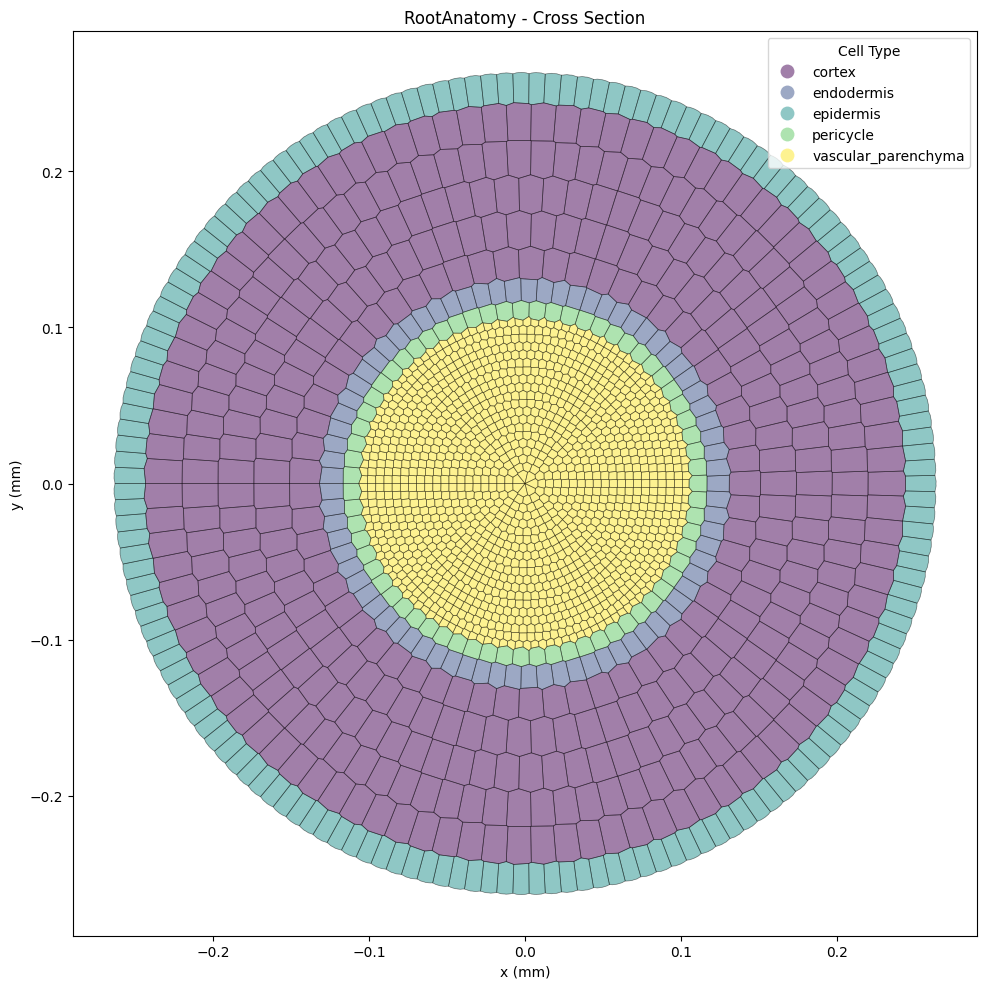

In [236]:
fig = root.plot_cells(show=True)
plt.savefig('output/root_initial_cells.png', dpi=150, bbox_inches='tight')
plt.close()

### 3. Get statistics

In [237]:
stats = root.get_statistics()
print("\n Anatomical statistics:")
print(f"   Total cells: {stats['total_cells']}")
print(f"   Cell types: {', '.join(stats['cell_types'])}")
print(f"   Total area: {stats['total_area']:.4f} mm²")


 Anatomical statistics:
   Total cells: 2030
   Cell types: epidermis, cortex, endodermis, pericycle, vascular_parenchyma
   Total area: 0.2174 mm²


### 4. Modify the anatomy

   Layers after addition: ['epidermis', 'cortex', 'endodermis', 'pericycle', 'exodermis']


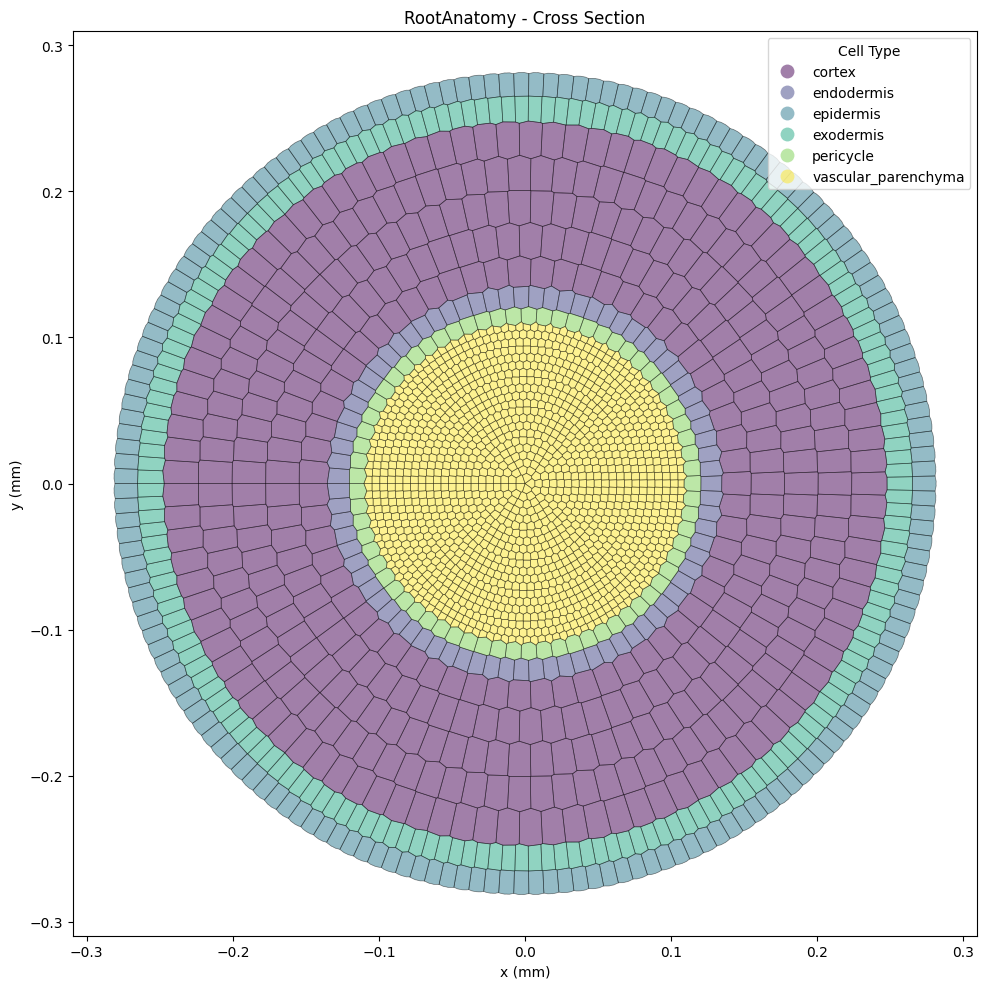

In [238]:
# add a new layer (exodermis) between cortex and epidermis
exodermis = Layer(
    name="exodermis",
    cell_diameter=0.018,
    n_layers=1,
    order=4.5  # Between cortex (4) and epidermis (5)
)
root.add_layer(exodermis)
print(f"   Layers after addition: {root.list_layers()}")

fig = root.plot_cells(show=True)
plt.savefig('output/root_with_exodermis.png', dpi=150, bbox_inches='tight')
plt.close()

In [239]:
stats = root.get_statistics()
print("\n Anatomical statistics:")
print(f"   Total cells: {stats['total_cells']}")
print(f"   Cell types: {', '.join(stats['cell_types'])}")
print(f"   Total area: {stats['total_area']:.4f} mm²")


 Anatomical statistics:
   Total cells: 2326
   Cell types: epidermis, exodermis, cortex, endodermis, pericycle, vascular_parenchyma
   Total area: 0.2482 mm²


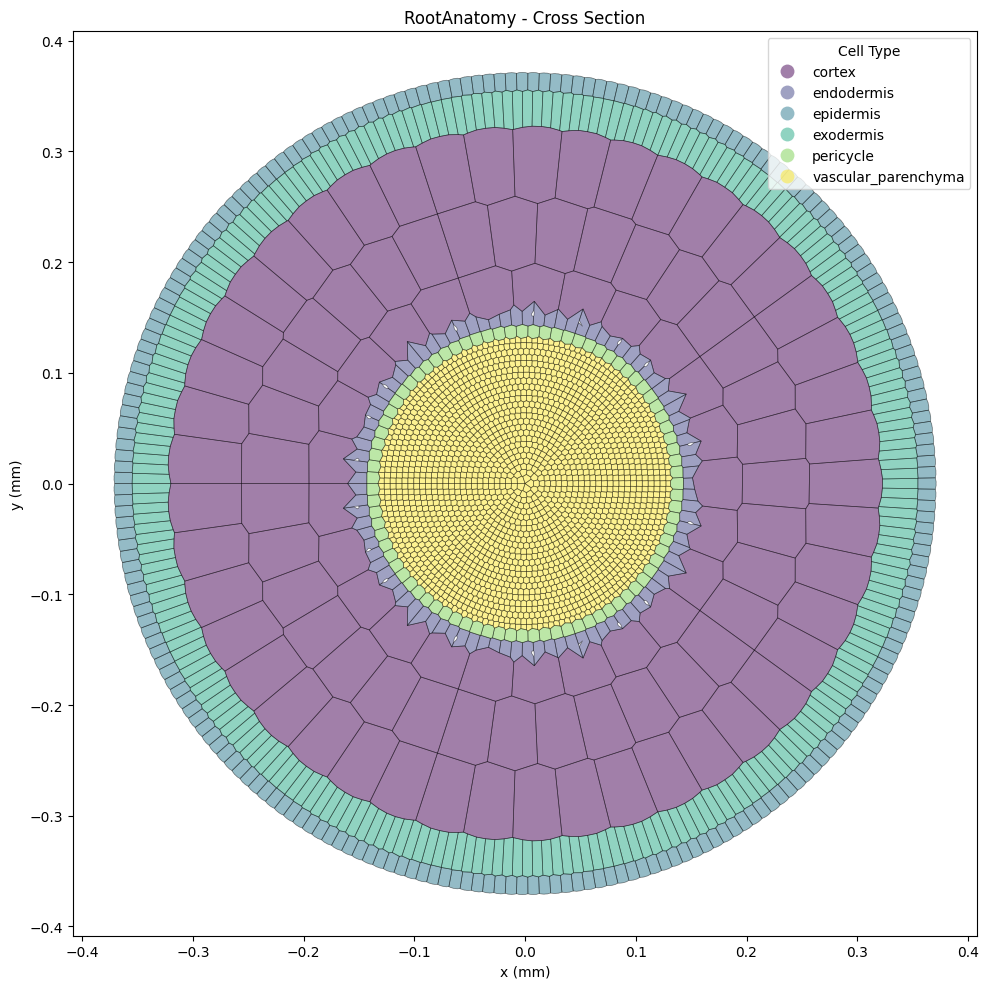

In [240]:
# Modify cortex layer
cortex = root.get_layer("cortex")
root.remove_layer("cortex")

# Create new cortex with different properties
new_cortex = Layer(
    name="cortex",
    cell_diameter=0.08,  # Larger cells
    n_layers=3,          # Fewer layers
    order=4
)
root.add_layer(new_cortex)

fig = root.plot_cells(show=True)
plt.savefig('output/root_modified_cortex.png', dpi=150, bbox_inches='tight')
plt.close()

### 5. Export

In [241]:
# Export data
root.export_to_csv('output/root_cells.csv')

## PINE NEEDLE ANATOMY DEMONSTRATION

In [242]:
# Create a pine needle anatomy instance
needle = PineNeedleAnatomy(randomness=1.0)

print(f"\nInitial layers: {needle.list_layers()}")
print(f"Number of layers: {len(needle.layer_manager)}")


Initial layers: ['epidermis', 'hypodermis', 'mesophyll', 'endodermis']
Number of layers: 4


### 1. Generating initial structure

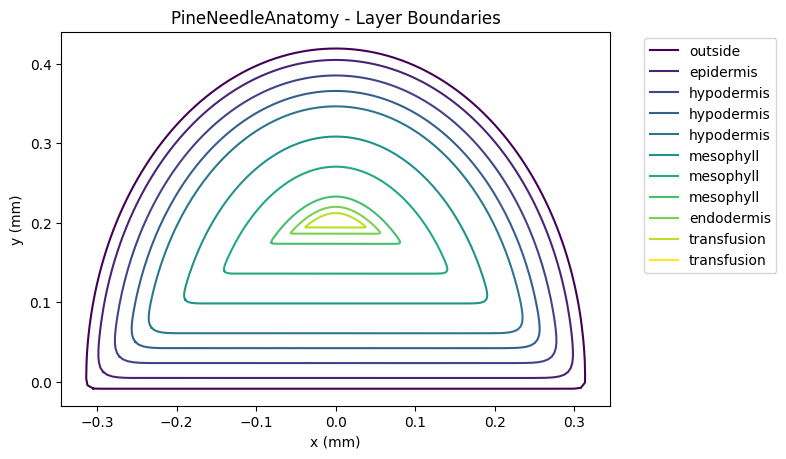

In [243]:
# Generate and plot the initial structure
fig = needle.plot_layers(show=True)
plt.savefig('output/needle_initial_layers.png', dpi=150, bbox_inches='tight')
plt.close()

### 2. Generating cell structure (Voronoi tessellation)

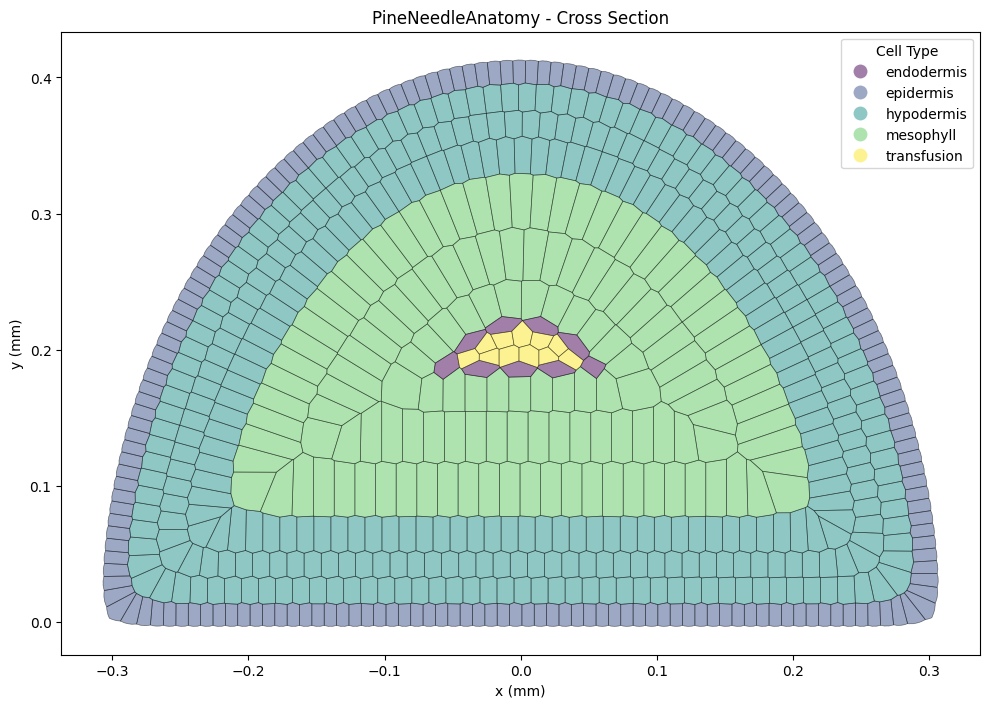

In [244]:
# Generate cells
fig = needle.plot_cells(show=True)
plt.savefig('output/needle_initial_cells.png', dpi=150, bbox_inches='tight')
plt.close()

### 3. Get statistics

In [245]:
# Get statistics
stats = needle.get_statistics()
print("\n Anatomical statistics:")
print(f"   Total cells: {stats['total_cells']}")
print(f"   Cell types: {', '.join(stats['cell_types'])}")
print(f"   Total area: {stats['total_area']:.4f} mm²")
print(f"   Mean cell area: {stats['mean_cell_area']:.6f} mm²")


 Anatomical statistics:
   Total cells: 673
   Cell types: epidermis, hypodermis, mesophyll, endodermis, transfusion
   Total area: 0.2012 mm²
   Mean cell area: 0.000299 mm²


### 4. Modify the anatomy


4. Adding a new 'sclerenchyma' layer...
   Layers after addition: ['epidermis', 'hypodermis', 'mesophyll', 'endodermis', 'sclerenchyma']


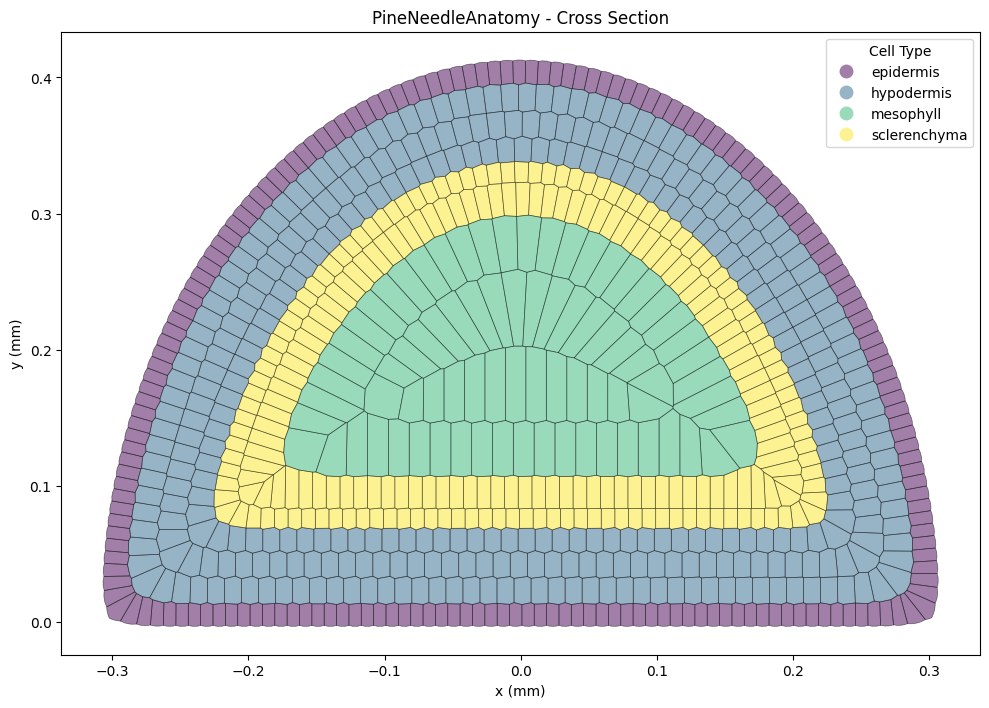

In [246]:

# Add a new layer
print("\n4. Adding a new 'sclerenchyma' layer...")
sclerenchyma = Layer(
    name="sclerenchyma",
    cell_diameter=0.02,
    n_layers=2,
    order=4.5  # Between mesophyll (4) and hypodermis (5)
)
needle.add_layer(sclerenchyma)
print(f"   Layers after addition: {needle.list_layers()}")

# Regenerate with new layer
fig = needle.plot_cells(show=True)
plt.savefig('output/needle_with_sclerenchyma.png', dpi=150, bbox_inches='tight')
plt.close()

   Removed: Layer(name='hypodermis', diameter=0.0250, n_layers=3, order=5)
   Layers after removal: ['epidermis', 'mesophyll', 'endodermis', 'sclerenchyma']


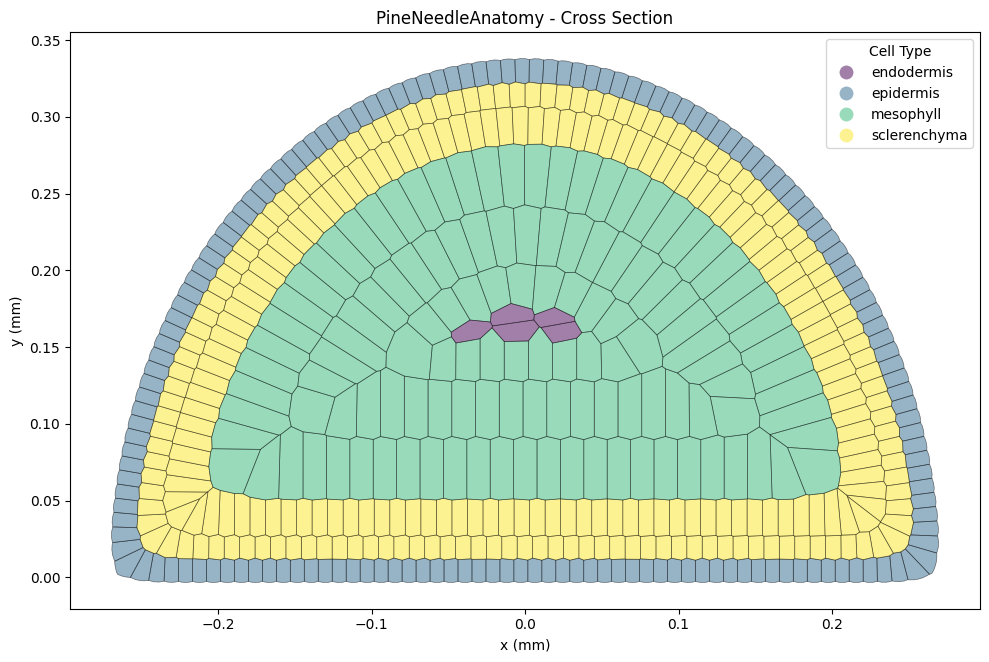

In [247]:
# Remove a layer
removed = needle.remove_layer("hypodermis")
print(f"   Removed: {removed}")
print(f"   Layers after removal: {needle.list_layers()}")

# Regenerate after removal
fig = needle.plot_cells(show=True)
plt.savefig('output/needle_without_hypodermis.png', dpi=150, bbox_inches='tight')
plt.close()

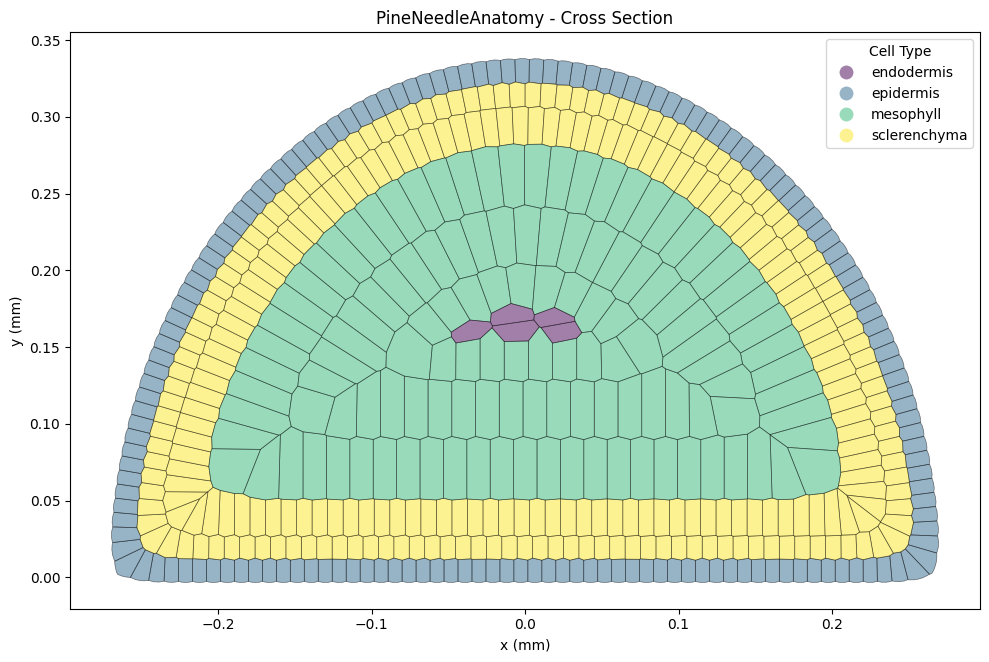

In [248]:
# Modify central cylinder parameters
needle.set_central_cylinder_params(
    transfusion_layers=5,
    cell_diameter=0.008
)
fig = needle.plot_cells(show=True)
plt.savefig('output/needle_modified_center.png', dpi=150, bbox_inches='tight')
plt.close()

### 5. Export

In [249]:
# Export data
needle.export_to_csv('needle_cells.csv')

## Side by side

<module 'matplotlib.pyplot' from '/home/dozturk/Documents/Project/Drooght/Model/GRANAP/granap/lib/python3.13/site-packages/matplotlib/pyplot.py'>

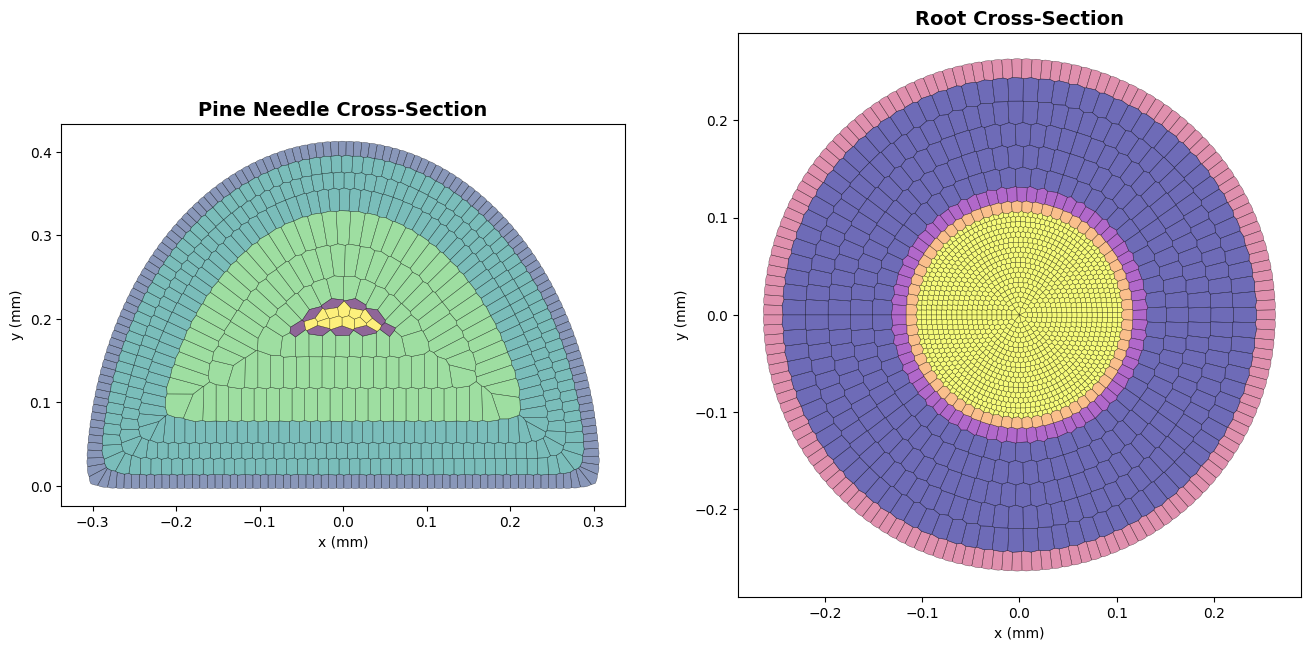

In [250]:
"""Create side-by-side comparison of both anatomy types."""

# Create both anatomies
needle = PineNeedleAnatomy()
root = RootAnatomy()

# Create comparison figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Plot needle
needle_cells = needle.generate_cells()
needle_cells.plot(
    ax=ax1,
    column='type',
    cmap='viridis',
    edgecolor='black',
    linewidth=0.3,
    alpha=0.6,
    legend=False
)
ax1.set_aspect('equal')
ax1.set_title('Pine Needle Cross-Section', fontsize=14, fontweight='bold')
ax1.set_xlabel('x (mm)')
ax1.set_ylabel('y (mm)')

# Plot root
root_cells = root.generate_cells()
root_cells.plot(
    ax=ax2,
    column='type',
    cmap='plasma',
    edgecolor='black',
    linewidth=0.3,
    alpha=0.6,
    legend=False
)
ax2.set_aspect('equal')
ax2.set_title('Root Cross-Section', fontsize=14, fontweight='bold')
ax2.set_xlabel('x (mm)')
ax2.set_ylabel('y (mm)')

plt
